Device: cuda
Generating train split...
Generating val split...
Saved dataset to: /workspaces/URM2/NCA_datas/continuous_nca_dataset_colab_demo
Train input_ids shape: (128, 2048)
Train labels shape: (128, 2048)
Train trajectories shape: (128, 32, 10, 10)
Train quantized trajectories shape: (128, 32, 10, 10)
Train visible range: -0.9962705373764038 0.9964314103126526
Train gzip ratio mean ± std: 0.5536792278289795 0.08273698389530182
Val gzip ratio mean ± std: 0.5570214986801147 0.0822133719921112
Grid shape: (10, 10)
State channels: 8
Visible channel: 0
Quantization bins: 16
Vocabulary size: 65538
Tokens per frame: 27


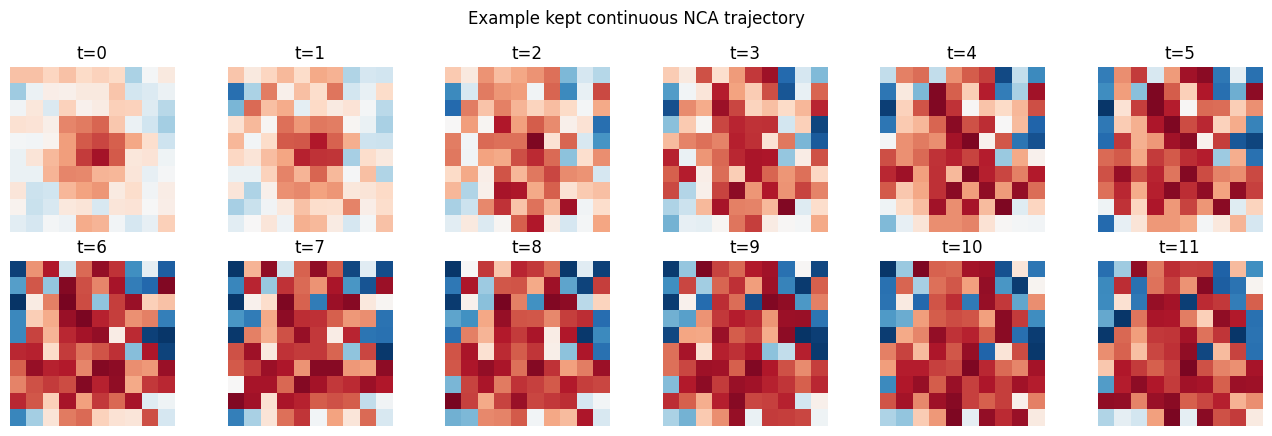

Frame shape: (10, 10)
Tokens per frame: 27
Start token: 65536 End token: 65537
First 16 patch tokens: [30122, 34985, 34969, 27225, 30343, 39303, 47254, 52360, 31385, 22102, 38775, 47800, 60892, 36028, 31081, 26743]
Quantization bins used: 5 to 14
Round-trip MAE after quantization: 0.029923


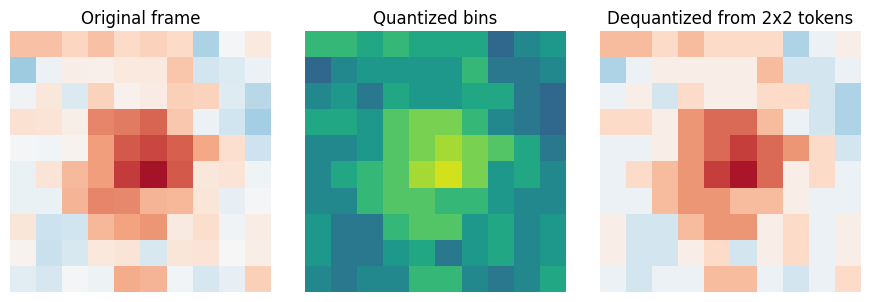

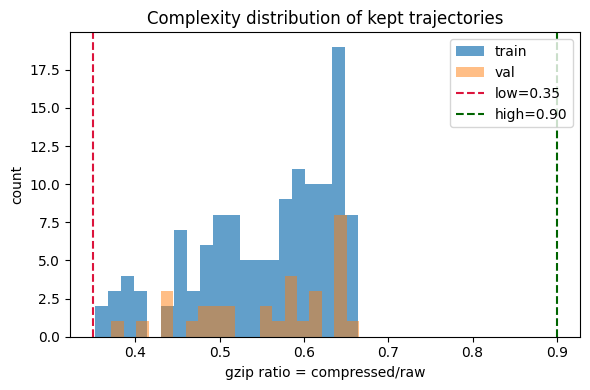

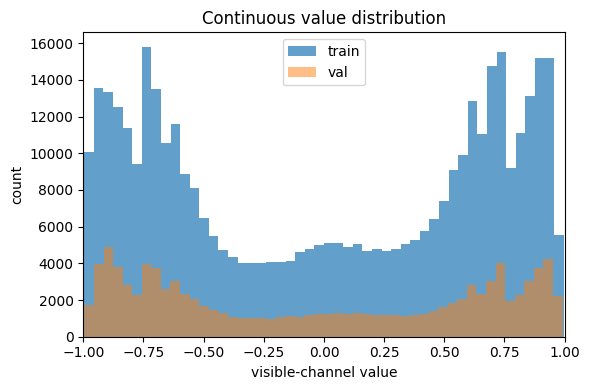

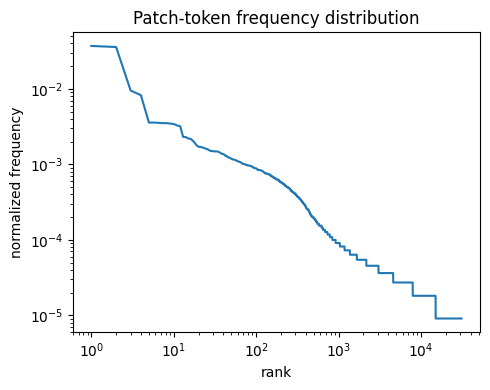

In [ ]:
# Colab-friendly continuous-state NCA pre-pre-training data generator
# Based on:
# - "Training Language Models via Neural Cellular Automata" (arXiv:2603.10055)
# - the user-provided NCA generation/tokenization codebase
#
# Usage in Colab:
#   1) Paste this whole file into a cell, or save it as continuous_nca_prepretraining_data_generator_colab.py
#   2) Run the bottom example block.
#
# What this notebook does:
#   - samples random continuous-state NCA rules
#   - rolls out float-valued visible trajectories
#   - quantizes visible frames into bins for gzip filtering and tokenization
#   - saves train/val arrays and metadata
#   - visualizes trajectories, value histograms, complexity histograms, and token frequencies

from __future__ import annotations

import importlib
import math
from pathlib import Path
from typing import Dict, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import animation

import sys

module_search_dirs = [Path.cwd(), Path.cwd() / "NCA_datas"]
module_dir = next((path for path in module_search_dirs if (path / "NCA_data_continuous.py").exists()), None)
if module_dir is None:
    raise FileNotFoundError("Could not find NCA_data_continuous.py from the current working directory.")
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

import NCA_data_continuous as continuous_nca_module

continuous_nca_module = importlib.reload(continuous_nca_module)
build_continuous_nca_dataset = continuous_nca_module.build_continuous_nca_dataset
ContinuousNCAConfig = continuous_nca_module.ContinuousNCAConfig
ContinuousNCATokenizer = continuous_nca_module.ContinuousNCATokenizer


# ============================================================
# Visualization
# ============================================================

def figure_size_for_frame(frame: np.ndarray, base_height: float = 3.0) -> Tuple[float, float]:
    height, width = frame.shape
    return base_height * (width / height), base_height


def show_trajectory_grid(
    cfg: ContinuousNCAConfig,
    traj: np.ndarray,
    title: str = "Trajectory",
    max_frames: int = 12,
) -> None:
    total = min(len(traj), max_frames)
    cols = min(6, total)
    rows = math.ceil(total / cols)
    frame_width, frame_height = figure_size_for_frame(traj[0], base_height=2.2)

    fig, axes = plt.subplots(rows, cols, figsize=(frame_width * cols, frame_height * rows))
    axes = np.array(axes).reshape(rows, cols)
    for i in range(rows * cols):
        ax = axes.flat[i]
        ax.axis("off")
        if i < total:
            ax.imshow(
                traj[i],
                cmap="RdBu_r",
                vmin=cfg.visible_min,
                vmax=cfg.visible_max,
                interpolation="nearest",
            )
            ax.set_title(f"t={i}")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_gzip_hist(
    train_gzip: np.ndarray,
    val_gzip: np.ndarray,
    threshold_low: float,
    threshold_high: Optional[float],
) -> None:
    plt.figure(figsize=(6, 4))
    plt.hist(train_gzip, bins=20, alpha=0.7, label="train")
    plt.hist(val_gzip, bins=20, alpha=0.5, label="val")
    plt.axvline(threshold_low, color="crimson", linestyle="--", label=f"low={threshold_low:.2f}")
    if threshold_high is not None:
        plt.axvline(threshold_high, color="darkgreen", linestyle="--", label=f"high={threshold_high:.2f}")
    plt.xlabel("gzip ratio = compressed/raw")
    plt.ylabel("count")
    plt.title("Complexity distribution of kept trajectories")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_value_hist(train_traj: np.ndarray, val_traj: np.ndarray, cfg: ContinuousNCAConfig) -> None:
    plt.figure(figsize=(6, 4))
    plt.hist(train_traj.reshape(-1), bins=50, alpha=0.7, label="train")
    plt.hist(val_traj.reshape(-1), bins=50, alpha=0.5, label="val")
    plt.xlim(cfg.visible_min, cfg.visible_max)
    plt.xlabel("visible-channel value")
    plt.ylabel("count")
    plt.title("Continuous value distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_token_frequency_loglog(input_ids: np.ndarray, ignore_value: int = -100) -> None:
    flat = input_ids.reshape(-1)
    flat = flat[flat != ignore_value]
    _, counts = np.unique(flat, return_counts=True)
    counts = np.sort(counts)[::-1]
    ranks = np.arange(1, len(counts) + 1)

    plt.figure(figsize=(5, 4))
    plt.loglog(ranks, counts / counts.sum())
    plt.xlabel("rank")
    plt.ylabel("normalized frequency")
    plt.title("Patch-token frequency distribution")
    plt.tight_layout()
    plt.show()


def inspect_tokenization_example(cfg: ContinuousNCAConfig, traj: np.ndarray) -> None:
    tokenizer = ContinuousNCATokenizer(cfg)
    frame = traj[0]
    frame_tokens = tokenizer.encode_frame(frame)
    quantized = tokenizer.quantize_frame(frame)
    decoded = tokenizer.decode_frame(frame_tokens[1:-1])
    mae = float(np.abs(frame - decoded).mean())

    print("Frame shape:", frame.shape)
    print("Tokens per frame:", len(frame_tokens))
    print("Start token:", frame_tokens[0], "End token:", frame_tokens[-1])
    print("First 16 patch tokens:", frame_tokens[1:17].tolist())
    print("Quantization bins used:", int(quantized.min()), "to", int(quantized.max()))
    print("Round-trip MAE after quantization:", round(mae, 6))

    frame_width, frame_height = figure_size_for_frame(frame, base_height=3.0)
    fig, axes = plt.subplots(1, 3, figsize=(frame_width * 3, frame_height))
    axes[0].imshow(
        frame,
        cmap="RdBu_r",
        vmin=cfg.visible_min,
        vmax=cfg.visible_max,
        interpolation="nearest",
    )
    axes[0].set_title("Original frame")
    axes[0].axis("off")
    axes[1].imshow(
        quantized,
        cmap="viridis",
        vmin=0,
        vmax=cfg.num_bins - 1,
        interpolation="nearest",
    )
    axes[1].set_title("Quantized bins")
    axes[1].axis("off")
    axes[2].imshow(
        decoded,
        cmap="RdBu_r",
        vmin=cfg.visible_min,
        vmax=cfg.visible_max,
        interpolation="nearest",
    )
    axes[2].set_title("Dequantized from 2x2 tokens")
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()


def make_animation_html(cfg: ContinuousNCAConfig, traj: np.ndarray, interval_ms: int = 300):
    from IPython.display import HTML

    fig = plt.figure(figsize=figure_size_for_frame(traj[0], base_height=3.0))
    ax = fig.add_subplot(111)
    im = ax.imshow(
        traj[0],
        cmap="RdBu_r",
        vmin=cfg.visible_min,
        vmax=cfg.visible_max,
        interpolation="nearest",
    )
    ax.axis("off")

    def update(i: int):
        im.set_data(traj[i])
        ax.set_title(f"t={i}")
        return [im]

    ani = animation.FuncAnimation(fig, update, frames=len(traj), interval=interval_ms, blit=True)
    plt.close(fig)
    return HTML(ani.to_jshtml())


def visualize_dataset(
    cfg: ContinuousNCAConfig,
    train: Dict[str, np.ndarray],
    val: Dict[str, np.ndarray],
) -> None:
    print("Train input_ids shape:", train["input_ids"].shape)
    print("Train labels shape:", train["labels"].shape)
    print("Train trajectories shape:", train["trajectories"].shape)
    print("Train quantized trajectories shape:", train["quantized_trajectories"].shape)
    print("Train visible range:", float(train["trajectories"].min()), float(train["trajectories"].max()))
    print("Train gzip ratio mean ± std:", float(train["gzip_ratio"].mean()), float(train["gzip_ratio"].std()))
    print("Val gzip ratio mean ± std:", float(val["gzip_ratio"].mean()), float(val["gzip_ratio"].std()))
    print("Grid shape:", cfg.grid_shape)
    print("State channels:", cfg.state_channels)
    print("Visible channel:", cfg.visible_channel)
    print("Quantization bins:", cfg.num_bins)
    print("Vocabulary size:", cfg.total_vocab_size)
    print("Tokens per frame:", cfg.tokens_per_frame)

    show_trajectory_grid(cfg, train["trajectories"][0], title="Example kept continuous NCA trajectory")
    inspect_tokenization_example(cfg, train["trajectories"][0])
    plot_gzip_hist(train["gzip_ratio"], val["gzip_ratio"], cfg.gzip_threshold_low, cfg.gzip_threshold_high)
    plot_value_hist(train["trajectories"], val["trajectories"], cfg)
    plot_token_frequency_loglog(train["input_ids"])


# ============================================================
# Colab example
# ============================================================

if __name__ == "__main__":
    cfg = ContinuousNCAConfig(
        grid_height=10,
        grid_width=10,
        state_channels=8,
        visible_channel=0,
        clip_value=1.0,
        init_noise_std=0.15,
        init_blob_scale=1.0,
        init_blob_sigma=1.5,
        update_scale=0.25,
        fire_rate=0.7,
        conv_channels=16,
        hidden_dim=32,
        patch_size=2,
        num_bins=16,
        seq_len=2048,
        rollout_steps=32,
        time_subsample=1,
        start_step=0,
        gzip_threshold_low=0.35,
        gzip_threshold_high=0.45,
        train_size=128,
        val_size=32,
        batch_candidate_size=64,
        max_sampling_rounds=200,
        out_dir="./continuous_nca_dataset_colab_demo",
    )

    train, val = build_continuous_nca_dataset(cfg, seed=43)
    visualize_dataset(cfg, train, val)

    from IPython.display import display

    display(make_animation_html(cfg, train["trajectories"][0]))
